
# Credit Card Fraud Detection — EDA & Univariate Analysis

## Dataset
**Kaggle:** Credit Card Transactions Fraud Detection Dataset by `kartik2112`  
**Dataset link:** https://www.kaggle.com/datasets/kartik2112/fraud-detection

This notebook focuses on:

1. Dataset Understanding
2. Data Quality Report
3. Missing-value analysis and verification
4. Class-imbalance analysis
5. **Part 2 — Univariate Analysis**
6. Numerical variable distributions
7. Categorical variable distributions
8. Outlier analysis, especially `amt`
9. 1–2 meaningful observations for every major analysis

### Important scope
This notebook intentionally **does not repeat** the following analyses:
- amount vs fraud
- distance vs fraud
- category vs fraud
- hour vs fraud
- day vs fraud
- correlation heatmap
- other previously completed 3-variable / bivariate / multivariate analyses

All analysis requested here is kept under the clearly labelled **Part 2 — Univariate Analysis** section where appropriate.


In [1]:
# ============================================================
# 0. IMPORTS AND DISPLAY SETTINGS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns




## 1. Dataset Loading

The Kaggle dataset contains `fraudTrain.csv` and `fraudTest.csv`. The training file is normally used for EDA/model development.

The loader below checks common locations so that the notebook works in:
- Kaggle Notebook
- Google Colab
- Jupyter Notebook
- VS Code

If your CSV is in another folder, change `DATA_PATH`.


In [2]:
# ============================================================
# 1. LOAD DATA
# ============================================================

df = pd.read_csv("../archive (2)/fraudTrain.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!



# 2. DATASET UNDERSTANDING

## 2.1 Basic Structure

Before visual analysis, we inspect the dimensions, column names, data types, and a small sample. This establishes what each variable looks like and helps identify possible type problems.


In [3]:

# Shape
print("Rows:", f"{df.shape[0]:,}")
print("Columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

print("\nLast 5 rows:")
display(df.tail())


Rows: 1,296,675
Columns: 23

Column names:
['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud']

First 5 rows:


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0



Last 5 rows:


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
1296670,1296670,2020-06-21 12:12:08,30263540414123,fraud_Reichel Inc,entertainment,15.56,Erik,Patterson,M,162 Jessica Row Apt. 072,...,37.7175,-112.4777,258,Geoscientist,1961-11-24,440b587732da4dc1a6395aba5fb41669,1371816728,36.841266,-111.690765,0
1296671,1296671,2020-06-21 12:12:19,6011149206456997,fraud_Abernathy and Sons,food_dining,51.70,Jeffrey,White,M,8617 Holmes Terrace Suite 651,...,39.2667,-77.5101,100,"Production assistant, television",1979-12-11,278000d2e0d2277d1de2f890067dcc0a,1371816739,38.906881,-78.246528,0
1296672,1296672,2020-06-21 12:12:32,3514865930894695,fraud_Stiedemann Ltd,food_dining,105.93,Christopher,Castaneda,M,1632 Cohen Drive Suite 639,...,32.9396,-105.8189,899,Naval architect,1967-08-30,483f52fe67fabef353d552c1e662974c,1371816752,33.619513,-105.130529,0
1296673,1296673,2020-06-21 12:13:36,2720012583106919,"fraud_Reinger, Weissnat and Strosin",food_dining,74.90,Joseph,Murray,M,42933 Ryan Underpass,...,43.3526,-102.5411,1126,Volunteer coordinator,1980-08-18,d667cdcbadaaed3da3f4020e83591c83,1371816816,42.788940,-103.241160,0
1296674,1296674,2020-06-21 12:13:37,4292902571056973207,"fraud_Langosh, Wintheiser and Hyatt",food_dining,4.30,Jeffrey,Smith,M,135 Joseph Mountains,...,45.8433,-113.8748,218,"Therapist, horticultural",1995-08-16,8f7c8e4ab7f25875d753b422917c98c9,1371816817,46.565983,-114.186110,0


In [4]:

# Data types and non-null counts
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  str    
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  str    
 4   category               1296675 non-null  str    
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  str    
 7   last                   1296675 non-null  str    
 8   gender                 1296675 non-null  str    
 9   street                 1296675 non-null  str    
 10  city                   1296675 non-null  str    
 11  state                  1296675 non-null  str    
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long                   129667


## 2.2 Variable Groups

The following grouping is useful for the EDA:

### Important numerical variables requested
- `amt`
- `city_pop`
- `lat`
- `long`
- `merch_lat`
- `merch_long`

### Important categorical variables requested
- `category`
- `gender`
- `state`
- `job`

### Other useful categorical variables
- `merchant`
- `city`

The target `is_fraud` is also inspected separately for class balance.


In [5]:

# Automatically identify requested columns that actually exist
requested_numeric = ["amt", "city_pop", "lat", "long", "merch_lat", "merch_long"]
requested_categorical = ["category", "gender", "state", "job"]
top_n_categorical = ["merchant", "city"]

numeric_cols = [c for c in requested_numeric if c in df.columns]
categorical_cols = [c for c in requested_categorical if c in df.columns]
topn_cols = [c for c in top_n_categorical if c in df.columns]

print("Requested numerical variables found:", numeric_cols)
print("Requested categorical variables found:", categorical_cols)
print("Top-N categorical variables found:", topn_cols)


Requested numerical variables found: ['amt', 'city_pop', 'lat', 'long', 'merch_lat', 'merch_long']
Requested categorical variables found: ['category', 'gender', 'state', 'job']
Top-N categorical variables found: ['merchant', 'city']



# 3. DATA QUALITY REPORT

The data-quality stage checks:

- missing values
- missing-value percentage
- duplicate rows
- unique values
- data types
- constant / near-constant columns
- invalid numeric values
- negative transaction amounts
- basic numerical ranges


In [6]:

# ============================================================
# 3.1 COMPREHENSIVE DATA QUALITY REPORT
# ============================================================

quality_report = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "non_null": df.notna().sum(),
    "missing": df.isna().sum(),
    "missing_%": df.isna().mean() * 100,
    "unique_values": df.nunique(dropna=True),
})

quality_report["constant_column"] = quality_report["unique_values"].eq(1)
quality_report = quality_report.sort_values(
    ["missing_%", "unique_values"], ascending=[False, True]
)

display(quality_report)


,dtype,non_null,missing,missing_%,unique_values,constant_column
gender,str,1296675,0,0.0,2,False
is_fraud,int64,1296675,0,0.0,2,False
category,str,1296675,0,0.0,14,False
state,str,1296675,0,0.0,51,False
first,str,1296675,0,0.0,352,False
last,str,1296675,0,0.0,481,False
job,str,1296675,0,0.0,494,False
merchant,str,1296675,0,0.0,693,False
city_pop,int64,1296675,0,0.0,879,False
city,str,1296675,0,0.0,894,False


In [7]:

# ============================================================
# 3.2 MISSING-VALUE ANALYSIS
# ============================================================

missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(4)

missing_report = pd.DataFrame({
    "missing_count": missing,
    "missing_percentage": missing_pct
}).sort_values("missing_count", ascending=False)

display(missing_report[missing_report["missing_count"] > 0])

if missing.sum() == 0:
    print("Observation: No missing values are present in the dataset.")
else:
    cols_with_missing = missing[missing > 0].index.tolist()
    print(
        f"Observation: {len(cols_with_missing)} column(s) contain missing values. "
        "The table above shows their counts and percentages."
    )


,missing_count,missing_percentage


Observation: No missing values are present in the dataset.


In [8]:

# ============================================================
# 3.3 VISUAL MISSING-VALUE VERIFICATION
# ============================================================

if df.isna().sum().sum() == 0:
    print("No missing values to visualize.")
else:
    plt.figure(figsize=(12, 5))
    sns.heatmap(df.isna(), cbar=False, yticklabels=False)
    plt.title("Missing-Value Pattern")
    plt.xlabel("Columns")
    plt.ylabel("Rows")
    plt.show()


No missing values to visualize.


In [9]:

# ============================================================
# 3.4 DUPLICATE-ROW CHECK
# ============================================================

duplicate_count = df.duplicated().sum()
duplicate_pct = duplicate_count / len(df) * 100

print(f"Duplicate rows: {duplicate_count:,}")
print(f"Duplicate percentage: {duplicate_pct:.4f}%")

if duplicate_count == 0:
    print("Observation: No exact duplicate rows were found.")
else:
    print("Observation: Exact duplicate rows exist and should be investigated before modeling.")


Duplicate rows: 0
Duplicate percentage: 0.0000%
Observation: No exact duplicate rows were found.


In [10]:

# ============================================================
# 3.5 NUMERICAL SANITY CHECKS
# ============================================================

for col in numeric_cols:
    s = pd.to_numeric(df[col], errors="coerce")
    print(f"\n--- {col} ---")
    print("Minimum :", s.min())
    print("Maximum :", s.max())
    print("Mean    :", s.mean())
    print("Median  :", s.median())
    print("Invalid/non-numeric after coercion:", s.isna().sum())

if "amt" in df.columns:
    negative_amt = (pd.to_numeric(df["amt"], errors="coerce") < 0).sum()
    zero_amt = (pd.to_numeric(df["amt"], errors="coerce") == 0).sum()

    print("\nTransaction amount checks")
    print("Negative amounts:", negative_amt)
    print("Zero amounts    :", zero_amt)



--- amt ---
Minimum : 1.0
Maximum : 28948.9
Mean    : 70.35103545607032
Median  : 47.52
Invalid/non-numeric after coercion: 0

--- city_pop ---
Minimum : 23
Maximum : 2906700
Mean    : 88824.44056297839
Median  : 2456.0
Invalid/non-numeric after coercion: 0

--- lat ---
Minimum : 20.0271
Maximum : 66.6933
Mean    : 38.53762161489964
Median  : 39.3543
Invalid/non-numeric after coercion: 0

--- long ---
Minimum : -165.6723
Maximum : -67.9503
Mean    : -90.22633537864152
Median  : -87.4769
Invalid/non-numeric after coercion: 0

--- merch_lat ---
Minimum : 19.027785
Maximum : 67.510267
Mean    : 38.537338044699716
Median  : 39.36568
Invalid/non-numeric after coercion: 0

--- merch_long ---
Minimum : -166.671242
Maximum : -66.950902
Mean    : -90.22646479897276
Median  : -87.43839200000001
Invalid/non-numeric after coercion: 0

Transaction amount checks
Negative amounts: 0
Zero amounts    : 0



# 4. CLASS-IMBALANCE ANALYSIS

`is_fraud` is the target variable. Because fraud detection is usually a highly imbalanced classification problem, both counts and percentages are reported.

This is a **univariate analysis of the target**, not a relationship between the target and another variable.


,count,percentage
is_fraud,,
0,1289169,99.4211
1,7506,0.5789


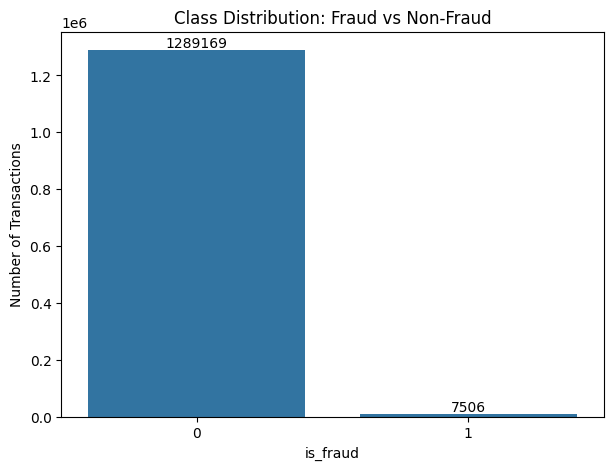

Observation: The target is strongly imbalanced, with the minority class representing approximately 0.58% of observations.
Observation: Accuracy alone would therefore be a weak metric for a future fraud-classification model; precision, recall, F1-score and PR-AUC should also be considered.


In [11]:

# ============================================================
# 4. CLASS DISTRIBUTION
# ============================================================

if "is_fraud" in df.columns:
    class_counts = df["is_fraud"].value_counts(dropna=False).sort_index()
    class_pct = df["is_fraud"].value_counts(normalize=True, dropna=False).sort_index() * 100

    class_report = pd.DataFrame({
        "count": class_counts,
        "percentage": class_pct.round(4)
    })

    display(class_report)

    plt.figure(figsize=(7, 5))
    ax = sns.countplot(data=df, x="is_fraud")
    plt.title("Class Distribution: Fraud vs Non-Fraud")
    plt.xlabel("is_fraud")
    plt.ylabel("Number of Transactions")

    for container in ax.containers:
        ax.bar_label(container, fmt="%.0f")

    plt.show()

    minority_pct = class_pct.min()
    print(
        f"Observation: The target is strongly imbalanced, with the minority class "
        f"representing approximately {minority_pct:.2f}% of observations."
    )
    print(
        "Observation: Accuracy alone would therefore be a weak metric for a future "
        "fraud-classification model; precision, recall, F1-score and PR-AUC should also be considered."
    )
else:
    print("Column 'is_fraud' was not found.")



# ============================================================
# PART 2 — UNIVARIATE ANALYSIS
# ============================================================

This section contains the requested univariate EDA only.

## Included
- numerical distributions
- histograms
- KDE plots
- boxplots
- categorical countplots/bar charts
- top 10 merchants
- top 10 cities
- outlier analysis
- IQR-based outlier counts
- 1–2 observations for each major analysis

## Explicitly excluded
To avoid duplication with previous work, this section does **not** include:
- amount vs fraud
- distance vs fraud
- category vs fraud
- hour vs fraud
- day vs fraud
- correlation heatmap
- other 3-variable analyses



## 5. Univariate Numerical Analysis

The requested numerical variables are:

`amt`, `city_pop`, `lat`, `long`, `merch_lat`, `merch_long`

For each variable, we use:
1. Histogram + KDE to understand distribution shape
2. Boxplot to inspect spread and potential outliers
3. Descriptive statistics
4. Skewness to identify asymmetry


In [12]:

# ============================================================
# 5.1 DESCRIPTIVE STATISTICS FOR NUMERICAL VARIABLES
# ============================================================

num_summary = df[numeric_cols].describe().T

num_summary["median"] = df[numeric_cols].median()
num_summary["skewness"] = df[numeric_cols].skew()
num_summary["missing"] = df[numeric_cols].isna().sum()

num_summary = num_summary[
    ["count", "missing", "mean", "median", "std", "min",
     "25%", "50%", "75%", "max", "skewness"]
]

display(num_summary)


,count,missing,mean,median,std,min,25%,50%,75%,max,skewness
amt,1296675.0,0,70.351035,47.520000,160.316039,1.000000,9.650000,47.520000,83.140000,2.894890e+04,42.277874
city_pop,1296675.0,0,88824.440563,2456.000000,301956.360689,23.000000,743.000000,2456.000000,20328.000000,2.906700e+06,5.593853
lat,1296675.0,0,38.537622,39.354300,5.075808,20.027100,34.620500,39.354300,41.940400,6.669330e+01,-0.186028
long,1296675.0,0,-90.226335,-87.476900,13.759077,-165.672300,-96.798000,-87.476900,-80.158000,-6.795030e+01,-1.150108
merch_lat,1296675.0,0,38.537338,39.365680,5.109788,19.027785,34.733572,39.365680,41.957164,6.751027e+01,-0.181915
merch_long,1296675.0,0,-90.226465,-87.438392,13.771091,-166.671242,-96.897276,-87.438392,-80.236796,-6.695090e+01,-1.146960


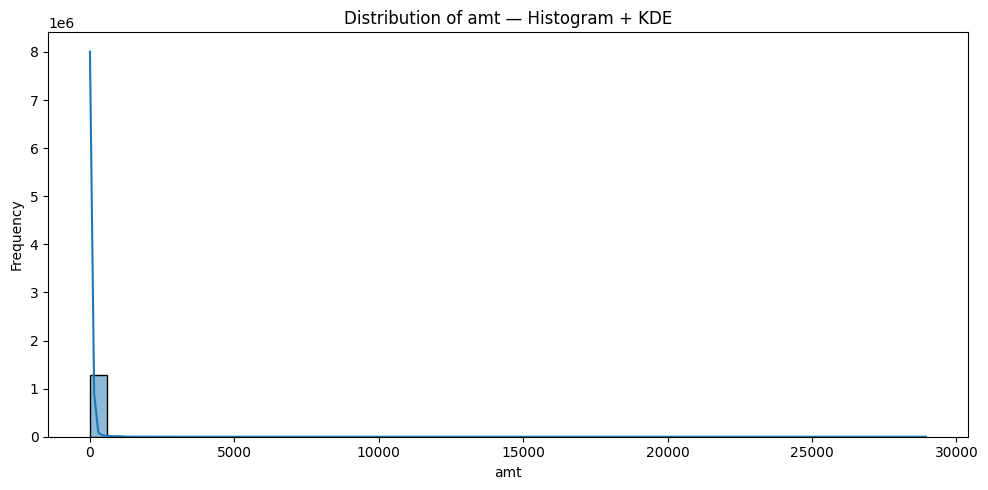

Observation for amt: The distribution is strongly right-skewed (skewness = 42.28). Median = 47.52, Mean = 70.35.


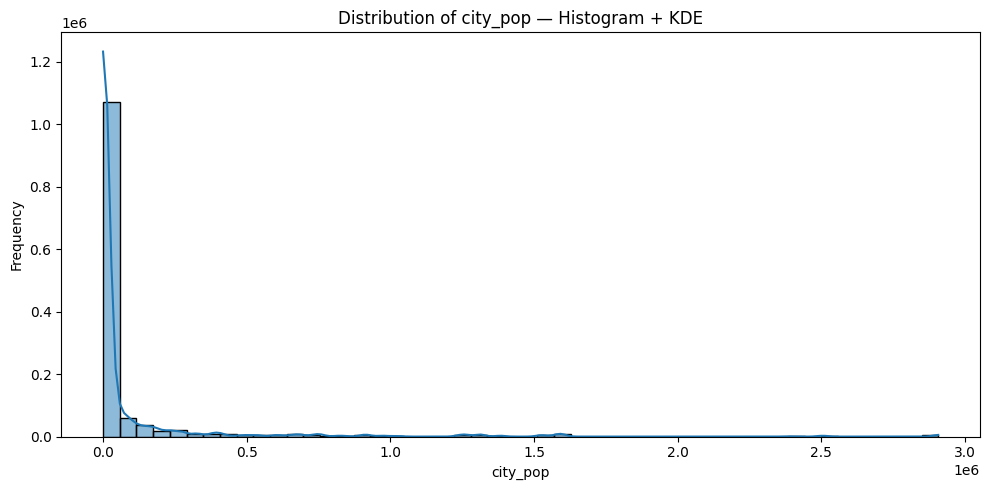

Observation for city_pop: The distribution is strongly right-skewed (skewness = 5.59). Median = 2456.00, Mean = 88824.44.


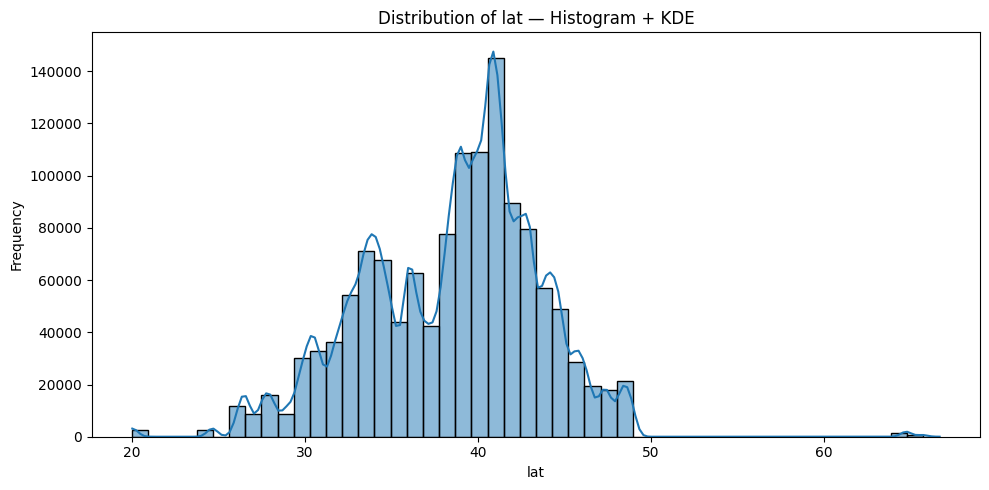

Observation for lat: The distribution is approximately symmetric (skewness = -0.19). Median = 39.35, Mean = 38.54.


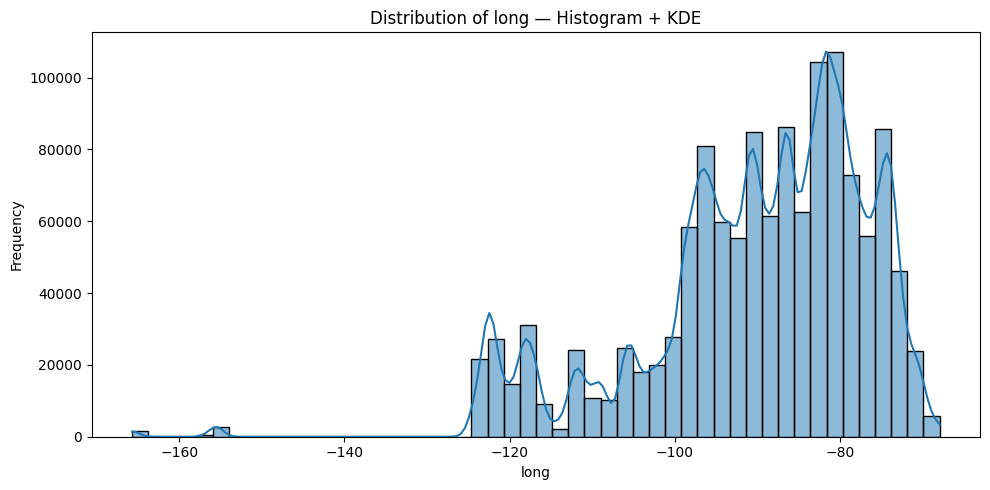

Observation for long: The distribution is strongly left-skewed (skewness = -1.15). Median = -87.48, Mean = -90.23.


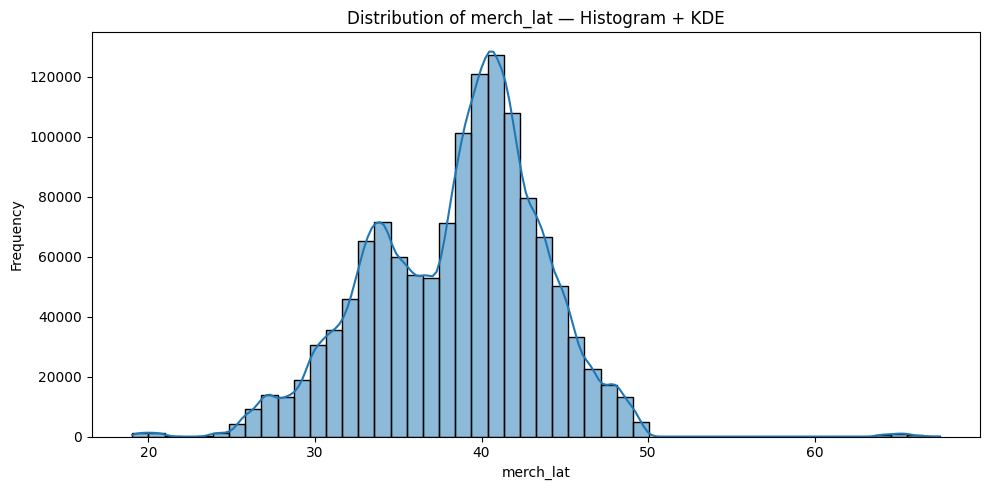

Observation for merch_lat: The distribution is approximately symmetric (skewness = -0.18). Median = 39.37, Mean = 38.54.


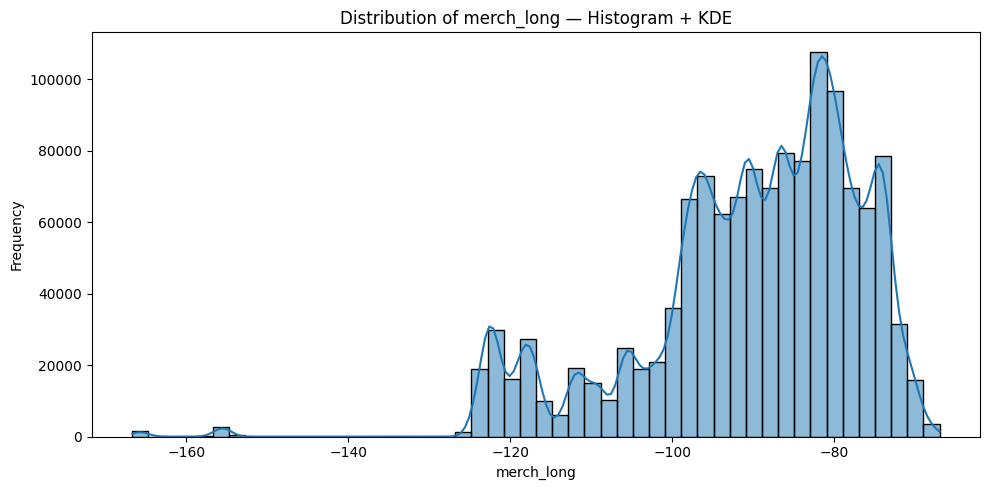

Observation for merch_long: The distribution is strongly left-skewed (skewness = -1.15). Median = -87.44, Mean = -90.23.


In [13]:

# ============================================================
# 5.2 HISTOGRAM + KDE FOR EACH NUMERICAL VARIABLE
# ============================================================

for col in numeric_cols:
    data = pd.to_numeric(df[col], errors="coerce").dropna()

    plt.figure(figsize=(10, 5))
    sns.histplot(data, bins=50, kde=True)
    plt.title(f"Distribution of {col} — Histogram + KDE")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

    skew = data.skew()

    if skew > 1:
        shape_note = "strongly right-skewed"
    elif skew > 0.5:
        shape_note = "moderately right-skewed"
    elif skew < -1:
        shape_note = "strongly left-skewed"
    elif skew < -0.5:
        shape_note = "moderately left-skewed"
    else:
        shape_note = "approximately symmetric"

    print(
        f"Observation for {col}: The distribution is {shape_note} "
        f"(skewness = {skew:.2f}). "
        f"Median = {data.median():.2f}, Mean = {data.mean():.2f}."
    )


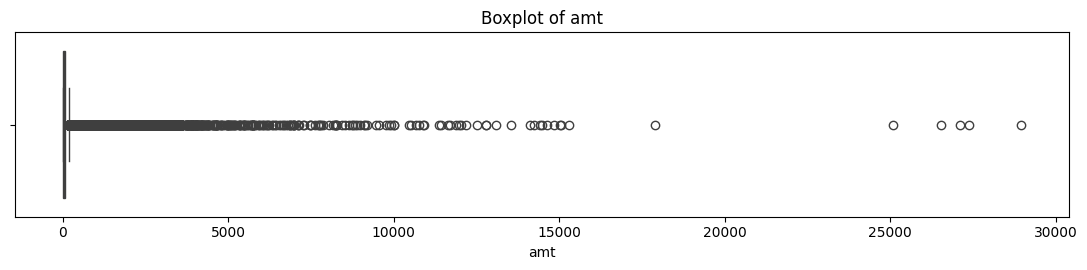

Observation for amt: The boxplot indicates a potential outlier count of 67,290 using the 1.5×IQR rule. The central 50% of values lies between 9.65 and 83.14.


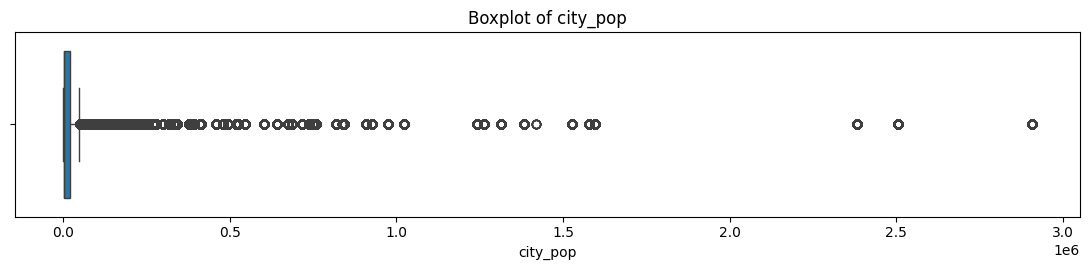

Observation for city_pop: The boxplot indicates a potential outlier count of 242,674 using the 1.5×IQR rule. The central 50% of values lies between 743.00 and 20328.00.


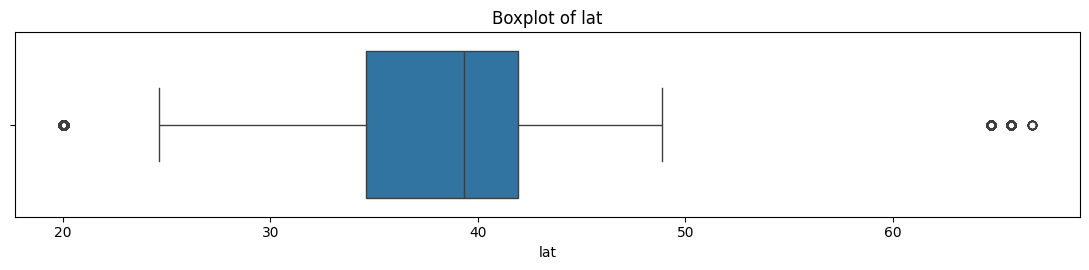

Observation for lat: The boxplot indicates a potential outlier count of 4,679 using the 1.5×IQR rule. The central 50% of values lies between 34.62 and 41.94.


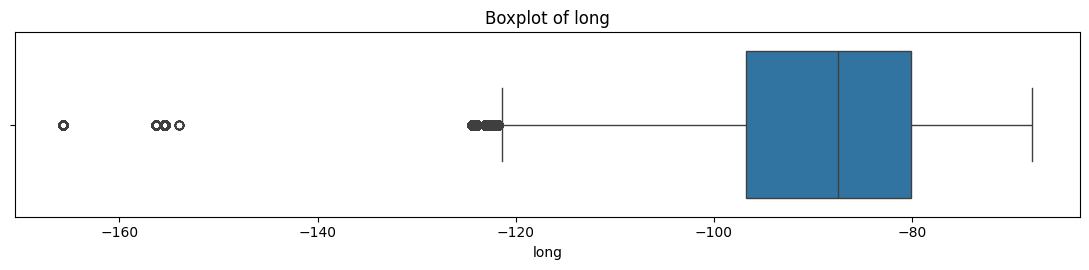

Observation for long: The boxplot indicates a potential outlier count of 49,922 using the 1.5×IQR rule. The central 50% of values lies between -96.80 and -80.16.


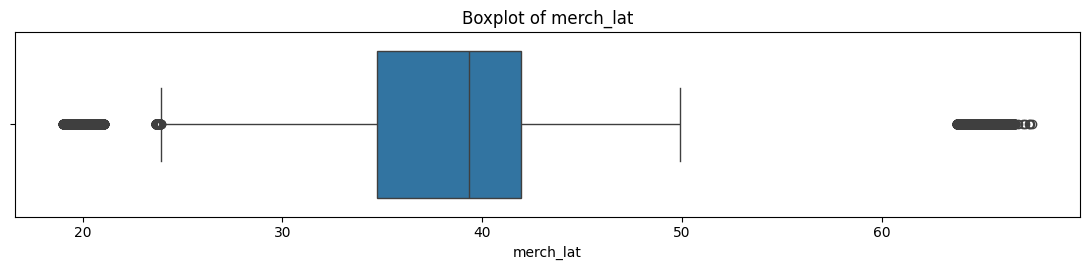

Observation for merch_lat: The boxplot indicates a potential outlier count of 4,967 using the 1.5×IQR rule. The central 50% of values lies between 34.73 and 41.96.


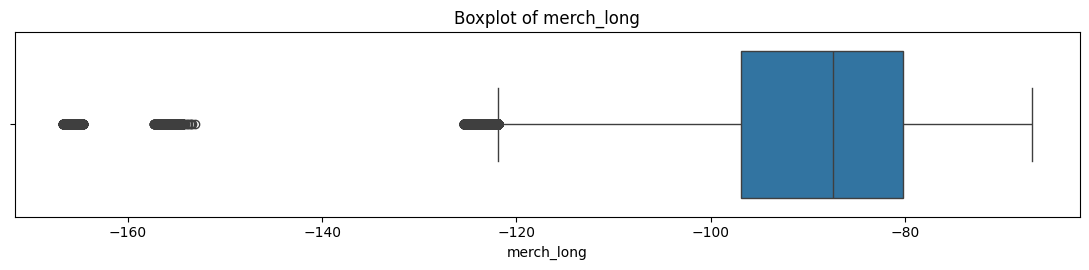

Observation for merch_long: The boxplot indicates a potential outlier count of 41,994 using the 1.5×IQR rule. The central 50% of values lies between -96.90 and -80.24.


In [14]:

# ============================================================
# 5.3 BOXPLOTS FOR EACH NUMERICAL VARIABLE
# ============================================================

for col in numeric_cols:
    data = pd.to_numeric(df[col], errors="coerce").dropna()

    plt.figure(figsize=(11, 2.8))
    sns.boxplot(x=data)
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    out_count = ((data < lower) | (data > upper)).sum()

    print(
        f"Observation for {col}: The boxplot indicates a potential outlier count "
        f"of {out_count:,} using the 1.5×IQR rule. "
        f"The central 50% of values lies between {q1:.2f} and {q3:.2f}."
    )



## 6. Detailed Transaction Amount (`amt`) Analysis

Transaction amount is especially important for data-quality and outlier inspection.

The analysis below remains **univariate**:
- overall amount distribution
- amount histogram/KDE
- amount boxplot
- IQR boundaries
- number and percentage of potential outliers
- extreme values

No `amt` vs `is_fraud` comparison is performed.


In [15]:

# ============================================================
# 6.1 DETAILED OUTLIER ANALYSIS — AMT
# ============================================================

if "amt" in df.columns:
    amt = pd.to_numeric(df["amt"], errors="coerce").dropna()

    Q1 = amt.quantile(0.25)
    Q3 = amt.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    amt_outliers = amt[(amt < lower_bound) | (amt > upper_bound)]

    print("Transaction Amount (`amt`) Outlier Analysis")
    print("-" * 55)
    print(f"Q1                    : {Q1:.2f}")
    print(f"Q3                    : {Q3:.2f}")
    print(f"IQR                   : {IQR:.2f}")
    print(f"Lower IQR bound       : {lower_bound:.2f}")
    print(f"Upper IQR bound       : {upper_bound:.2f}")
    print(f"Potential outliers    : {len(amt_outliers):,}")
    print(f"Outlier percentage    : {len(amt_outliers) / len(amt) * 100:.2f}%")
    print(f"Maximum amount        : {amt.max():.2f}")

    print("\nLargest 10 transaction amounts:")
    display(amt.nlargest(10).to_frame(name="amt"))

    print("\nInterpretation:")
    if amt.skew() > 1:
        print(
            "Observation 1: Transaction amount is strongly right-skewed, meaning "
            "a relatively small number of transactions have much larger amounts than the typical transaction."
        )
    else:
        print(
            "Observation 1: Transaction amount does not show extreme right-skewness "
            "under the current dataset."
        )

    print(
        "Observation 2: IQR-flagged observations are statistical potential outliers, "
        "not automatically errors or fraudulent transactions. They should be investigated "
        "before deciding whether to remove, cap, or transform them."
    )
else:
    print("Column 'amt' was not found.")


Transaction Amount (`amt`) Outlier Analysis
-------------------------------------------------------
Q1                    : 9.65
Q3                    : 83.14
IQR                   : 73.49
Lower IQR bound       : -100.58
Upper IQR bound       : 193.38
Potential outliers    : 67,290
Outlier percentage    : 5.19%
Maximum amount        : 28948.90

Largest 10 transaction amounts:


,amt
787549,28948.90
793677,27390.12
1234797,27119.77
606211,26544.12
352894,25086.94
187885,17897.24
1100138,15305.95
752016,15047.03
150564,15034.18
1245847,14849.74



Interpretation:
Observation 1: Transaction amount is strongly right-skewed, meaning a relatively small number of transactions have much larger amounts than the typical transaction.
Observation 2: IQR-flagged observations are statistical potential outliers, not automatically errors or fraudulent transactions. They should be investigated before deciding whether to remove, cap, or transform them.


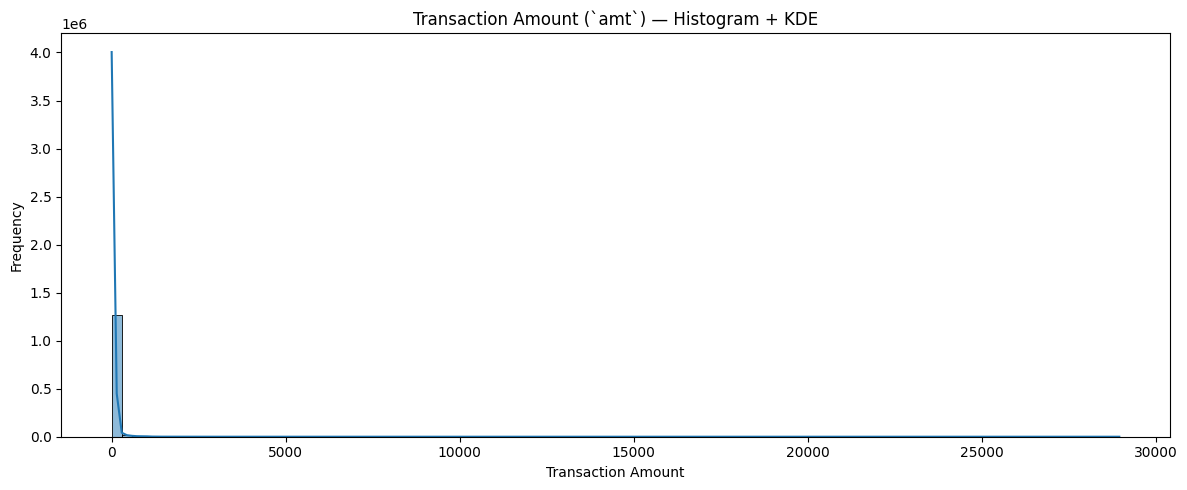

In [16]:

# ============================================================
# 6.2 AMOUNT HISTOGRAM / KDE
# ============================================================

if "amt" in df.columns:
    plt.figure(figsize=(12, 5))
    sns.histplot(df["amt"].dropna(), bins=100, kde=True)
    plt.title("Transaction Amount (`amt`) — Histogram + KDE")
    plt.xlabel("Transaction Amount")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()


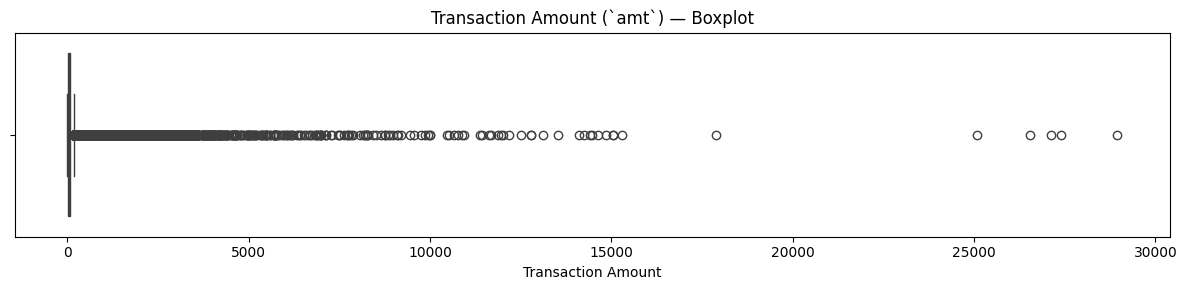

In [17]:

# ============================================================
# 6.3 AMOUNT BOXPLOT
# ============================================================

if "amt" in df.columns:
    plt.figure(figsize=(12, 3))
    sns.boxplot(x=df["amt"])
    plt.title("Transaction Amount (`amt`) — Boxplot")
    plt.xlabel("Transaction Amount")
    plt.tight_layout()
    plt.show()



## 7. Categorical Variable Distributions

Requested categorical variables:
- `category`
- `gender`
- `state`
- `job`

For high-cardinality variables, plotting every category would make the graph difficult to interpret. Therefore:
- `category` → all categories
- `gender` → all categories
- `state` → all states
- `job` → top 15 jobs
- `merchant` → top 10 merchants
- `city` → top 10 cities


In [18]:

# ============================================================
# 7.1 HELPER FUNCTION FOR CATEGORICAL COUNTPLOTS
# ============================================================

def categorical_countplot(data, column, top_n=None, title=None, rotate=0):
    series = data[column].dropna()

    if top_n is not None:
        order = series.value_counts().head(top_n).index
        plot_data = data[data[column].isin(order)].copy()
        order = series.value_counts().head(top_n).index
    else:
        plot_data = data.copy()
        order = series.value_counts().index

    plt.figure(figsize=(12, 6))
    ax = sns.countplot(
        data=plot_data,
        y=column if len(order) > 10 else None,
        x=None if len(order) > 10 else column,
        order=order if len(order) <= 10 else None,
        hue=None
    )

    # For horizontal plots, rebuild for cleaner ordering.
    plt.close()

    if len(order) > 10:
        plt.figure(figsize=(11, max(5, len(order) * 0.35)))
        ax = sns.countplot(data=plot_data, y=column, order=order)
        plt.xlabel("Number of Transactions")
        plt.ylabel(column)
    else:
        plt.figure(figsize=(10, 5))
        ax = sns.countplot(data=plot_data, x=column, order=order)
        plt.xlabel(column)
        plt.ylabel("Number of Transactions")
        plt.xticks(rotation=rotate)

    plt.title(title or f"Distribution of {column}")
    plt.tight_layout()
    plt.show()

    counts = series.value_counts()
    return counts


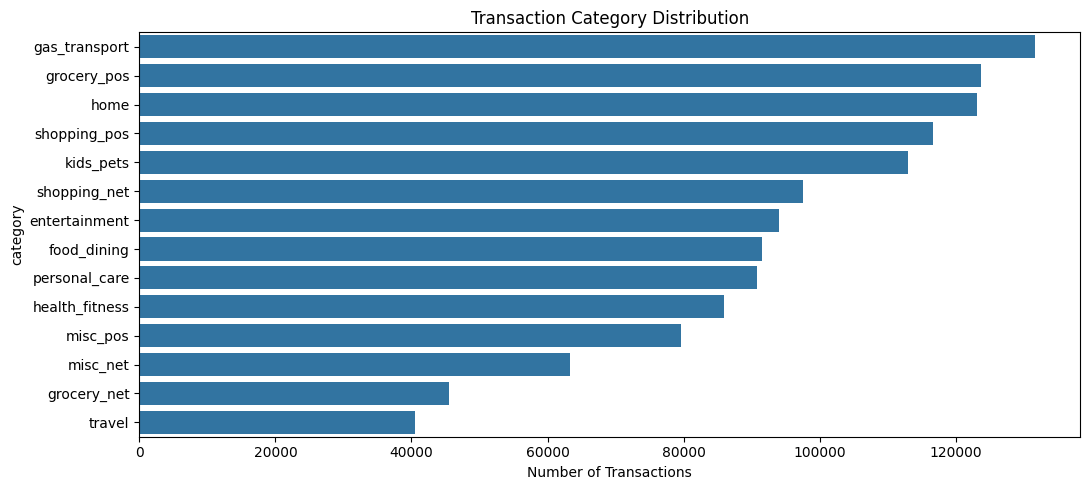

Top categories:


,count
category,
gas_transport,131659
grocery_pos,123638
home,123115
shopping_pos,116672
kids_pets,113035
shopping_net,97543
entertainment,94014
food_dining,91461
personal_care,90758


Observation 1: 'gas_transport' is the most frequent transaction category, accounting for approximately 10.15% of transactions.
Observation 2: There are 14 distinct transaction categories, so category frequency is reasonably interpretable without truncating the chart.


In [19]:

# ============================================================
# 7.2 CATEGORY DISTRIBUTION
# ============================================================

if "category" in df.columns:
    category_counts = categorical_countplot(
        df, "category",
        title="Transaction Category Distribution"
    )

    print("Top categories:")
    display(category_counts.head(10).to_frame("count"))

    top_category = category_counts.index[0]
    top_pct = category_counts.iloc[0] / category_counts.sum() * 100

    print(
        f"Observation 1: '{top_category}' is the most frequent transaction category, "
        f"accounting for approximately {top_pct:.2f}% of transactions."
    )
    print(
        f"Observation 2: There are {category_counts.size} distinct transaction categories, "
        "so category frequency is reasonably interpretable without truncating the chart."
    )


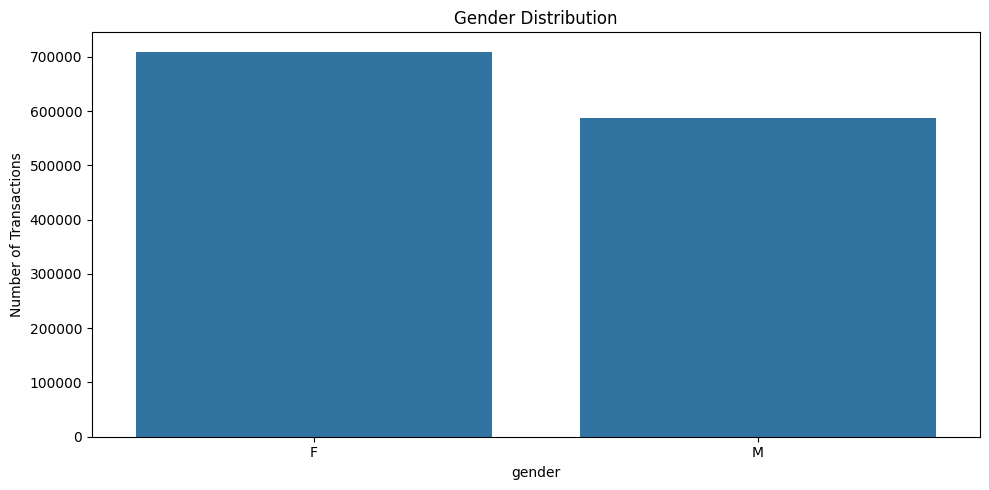

,count
gender,
F,709863
M,586812


Observation 1: 'F' is the more frequent gender category (54.74% of non-missing observations).
Observation 2: The distribution should be interpreted descriptively; this plot alone does not establish any relationship with fraud.


In [20]:

# ============================================================
# 7.3 GENDER DISTRIBUTION
# ============================================================

if "gender" in df.columns:
    gender_counts = categorical_countplot(
        df, "gender",
        title="Gender Distribution"
    )

    display(gender_counts.to_frame("count"))

    majority_gender = gender_counts.index[0]
    majority_pct = gender_counts.iloc[0] / gender_counts.sum() * 100

    print(
        f"Observation 1: '{majority_gender}' is the more frequent gender category "
        f"({majority_pct:.2f}% of non-missing observations)."
    )
    print(
        "Observation 2: The distribution should be interpreted descriptively; "
        "this plot alone does not establish any relationship with fraud."
    )


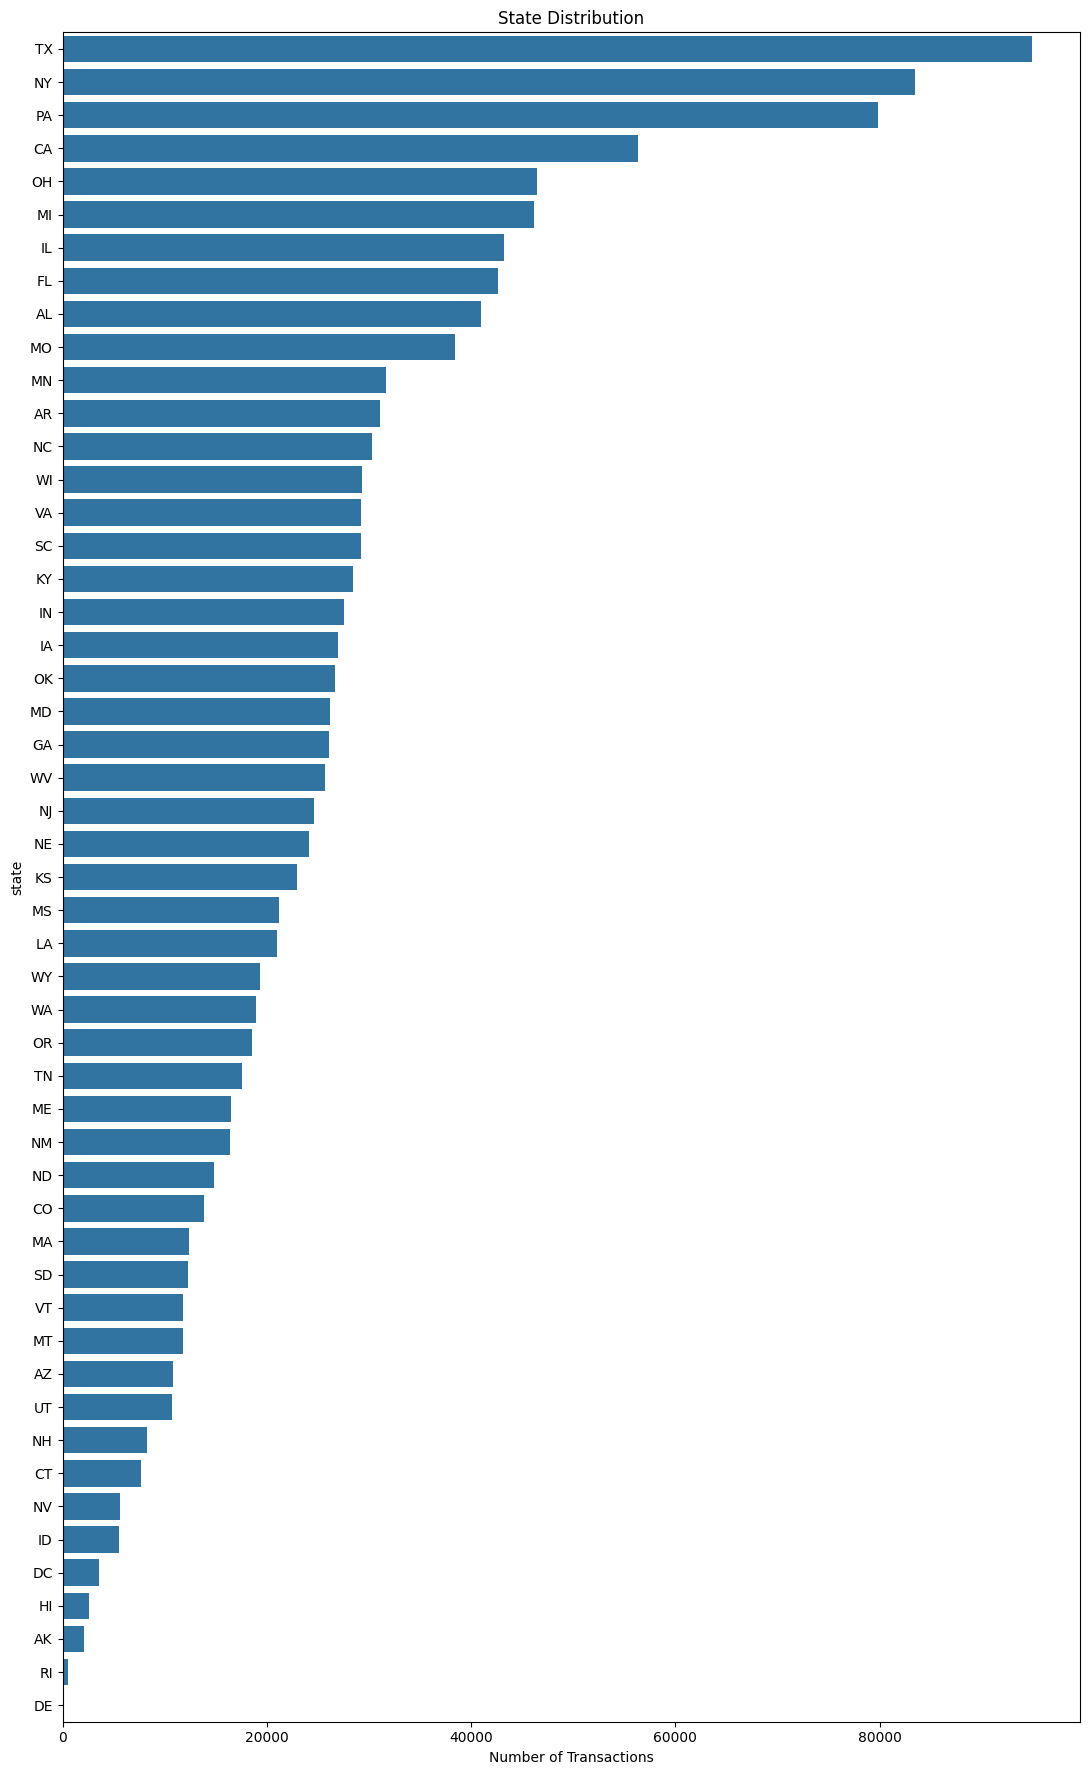

Top 10 states by transaction count:


,count
state,
TX,94876
NY,83501
PA,79847
CA,56360
OH,46480
MI,46154
IL,43252
FL,42671
AL,40989


Observation 1: The most represented state is 'TX', with 94,876 transactions.
Observation 2: Transaction volume is not uniform across states; some states contribute substantially more observations than others.


In [21]:

# ============================================================
# 7.4 STATE DISTRIBUTION
# ============================================================

if "state" in df.columns:
    state_counts = categorical_countplot(
        df, "state",
        title="State Distribution"
    )

    print("Top 10 states by transaction count:")
    display(state_counts.head(10).to_frame("count"))

    print(
        f"Observation 1: The most represented state is '{state_counts.index[0]}', "
        f"with {state_counts.iloc[0]:,} transactions."
    )
    print(
        "Observation 2: Transaction volume is not uniform across states; "
        "some states contribute substantially more observations than others."
    )


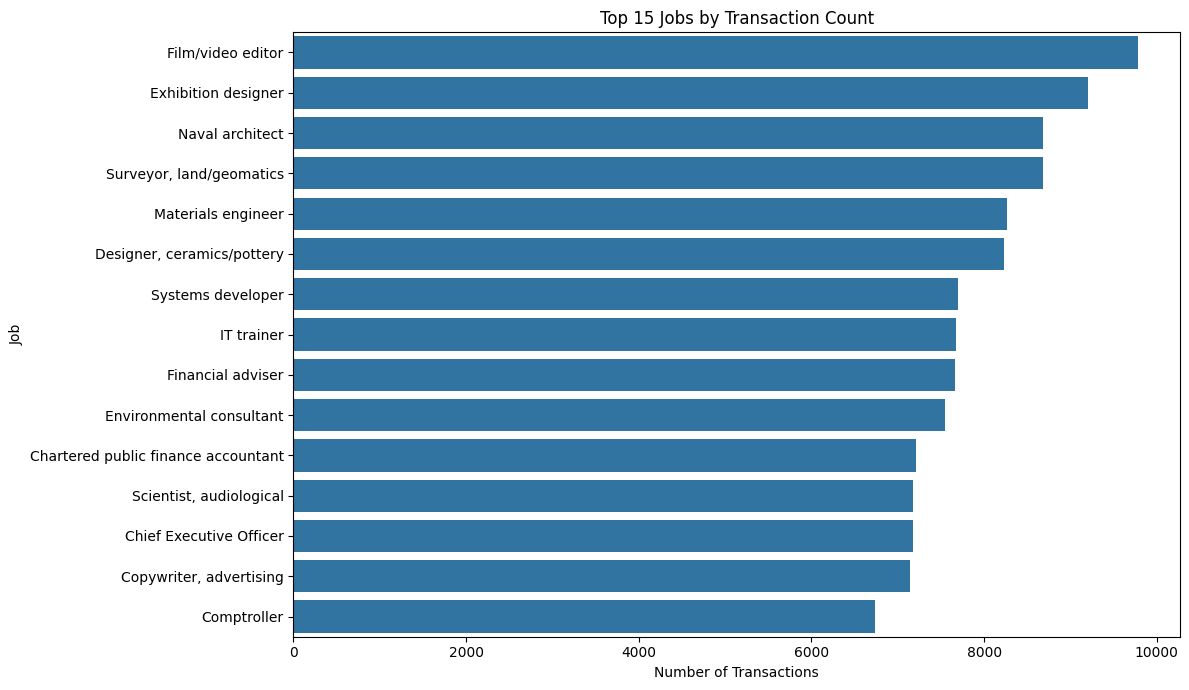

,count
job,
Film/video editor,9779
Exhibition designer,9199
Naval architect,8684
"Surveyor, land/geomatics",8680
Materials engineer,8270
"Designer, ceramics/pottery",8225
Systems developer,7700
IT trainer,7679
Financial adviser,7659


Observation 1: 'Film/video editor' is the most represented job among the top 15, with 9,779 transactions.
Observation 2: Job has relatively high cardinality, so a top-15 chart is more readable than plotting every unique job.


In [22]:

# ============================================================
# 7.5 JOB DISTRIBUTION — TOP 15
# ============================================================

if "job" in df.columns:
    job_counts = df["job"].dropna().value_counts()

    plt.figure(figsize=(12, 7))
    sns.barplot(
        x=job_counts.head(15).values,
        y=job_counts.head(15).index
    )
    plt.title("Top 15 Jobs by Transaction Count")
    plt.xlabel("Number of Transactions")
    plt.ylabel("Job")
    plt.tight_layout()
    plt.show()

    display(job_counts.head(15).to_frame("count"))

    print(
        f"Observation 1: '{job_counts.index[0]}' is the most represented job "
        f"among the top 15, with {job_counts.iloc[0]:,} transactions."
    )
    print(
        "Observation 2: Job has relatively high cardinality, so a top-15 chart "
        "is more readable than plotting every unique job."
    )


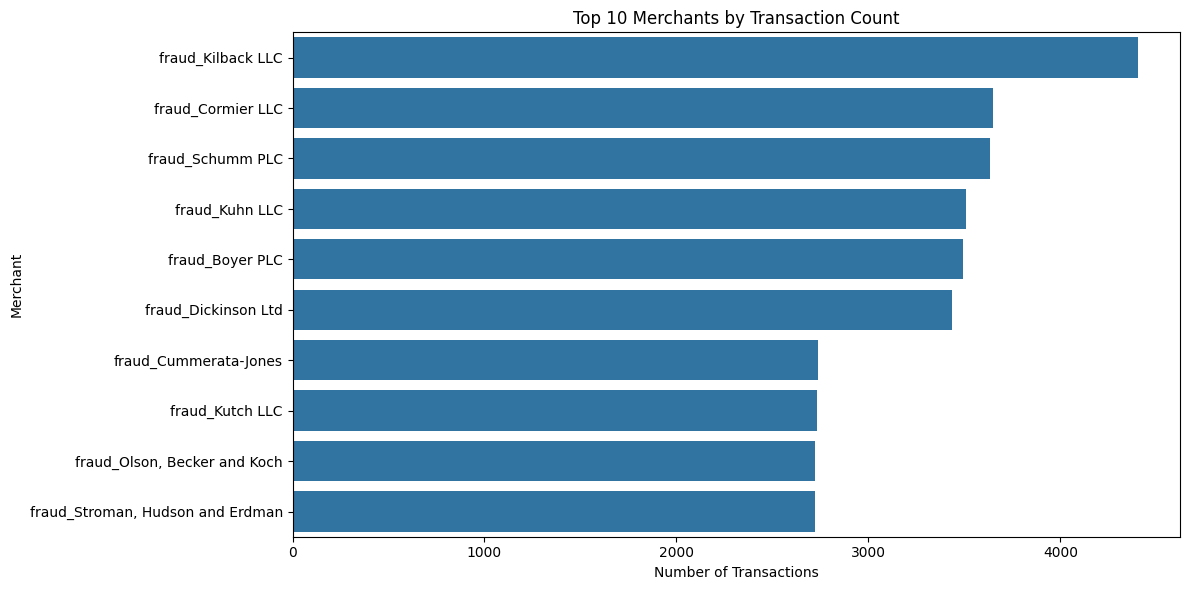

,count
merchant,
fraud_Kilback LLC,4403
fraud_Cormier LLC,3649
fraud_Schumm PLC,3634
fraud_Kuhn LLC,3510
fraud_Boyer PLC,3493
fraud_Dickinson Ltd,3434
fraud_Cummerata-Jones,2736
fraud_Kutch LLC,2734
"fraud_Olson, Becker and Koch",2723


Observation 1: The merchant with the highest transaction volume is 'fraud_Kilback LLC'.
Observation 2: Merchant frequencies are concentrated enough that the top-10 view gives a useful summary without plotting hundreds of unique merchants.


In [23]:

# ============================================================
# 7.6 TOP 10 MERCHANTS
# ============================================================

if "merchant" in df.columns:
    merchant_counts = df["merchant"].dropna().value_counts().head(10)

    plt.figure(figsize=(12, 6))
    sns.barplot(x=merchant_counts.values, y=merchant_counts.index)
    plt.title("Top 10 Merchants by Transaction Count")
    plt.xlabel("Number of Transactions")
    plt.ylabel("Merchant")
    plt.tight_layout()
    plt.show()

    display(merchant_counts.to_frame("count"))

    print(
        f"Observation 1: The merchant with the highest transaction volume is "
        f"'{merchant_counts.index[0]}'."
    )
    print(
        "Observation 2: Merchant frequencies are concentrated enough that the "
        "top-10 view gives a useful summary without plotting hundreds of unique merchants."
    )


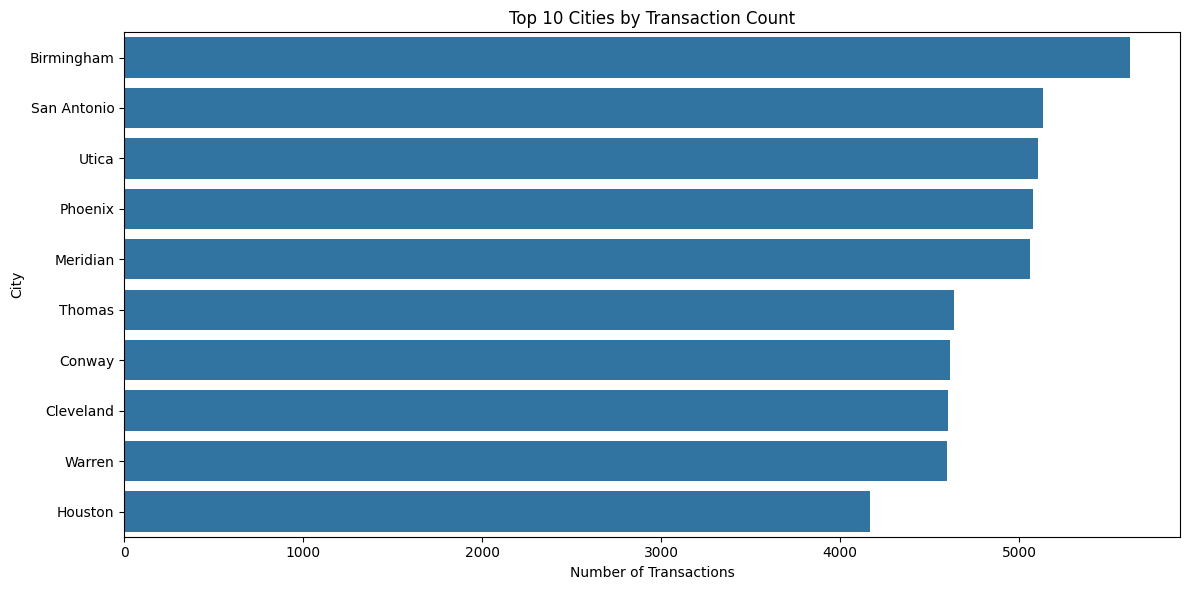

,count
city,
Birmingham,5617
San Antonio,5130
Utica,5105
Phoenix,5075
Meridian,5060
Thomas,4634
Conway,4613
Cleveland,4604
Warren,4599


Observation 1: 'Birmingham' has the highest transaction volume among the cities in the dataset.
Observation 2: City is a high-cardinality variable, therefore a top-10 summary is more readable and informative than a full countplot.


In [24]:

# ============================================================
# 7.7 TOP 10 CITIES
# ============================================================

if "city" in df.columns:
    city_counts = df["city"].dropna().value_counts().head(10)

    plt.figure(figsize=(12, 6))
    sns.barplot(x=city_counts.values, y=city_counts.index)
    plt.title("Top 10 Cities by Transaction Count")
    plt.xlabel("Number of Transactions")
    plt.ylabel("City")
    plt.tight_layout()
    plt.show()

    display(city_counts.to_frame("count"))

    print(
        f"Observation 1: '{city_counts.index[0]}' has the highest transaction volume "
        "among the cities in the dataset."
    )
    print(
        "Observation 2: City is a high-cardinality variable, therefore a top-10 "
        "summary is more readable and informative than a full countplot."
    )



## 8. General Numerical Outlier Analysis

The 1.5 × IQR rule is applied to each requested numerical variable.

### Formula

- `IQR = Q3 − Q1`
- Lower bound = `Q1 − 1.5 × IQR`
- Upper bound = `Q3 + 1.5 × IQR`

Values outside these bounds are **potential statistical outliers**.

Important: an IQR outlier is not automatically a data-entry error. In transaction data, extreme values may be legitimate observations.


In [25]:

# ============================================================
# 8.1 IQR OUTLIER SUMMARY FOR ALL REQUESTED NUMERICAL VARIABLES
# ============================================================

outlier_rows = []

for col in numeric_cols:
    s = pd.to_numeric(df[col], errors="coerce").dropna()

    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    mask = (s < lower) | (s > upper)
    count = mask.sum()

    outlier_rows.append({
        "variable": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "lower_bound": lower,
        "upper_bound": upper,
        "outlier_count": count,
        "outlier_%": count / len(s) * 100
    })

outlier_summary = pd.DataFrame(outlier_rows).sort_values(
    "outlier_%", ascending=False
)

display(outlier_summary)


,variable,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count,outlier_%
1,city_pop,743.000000,20328.000000,19585.000000,-28634.500000,49705.500000,242674,18.715098
0,amt,9.650000,83.140000,73.490000,-100.585000,193.375000,67290,5.189427
3,long,-96.798000,-80.158000,16.640000,-121.758000,-55.198000,49922,3.850001
5,merch_long,-96.897276,-80.236796,16.660479,-121.887994,-55.246078,41994,3.238591
4,merch_lat,34.733572,41.957164,7.223592,23.898184,52.792552,4967,0.383057
2,lat,34.620500,41.940400,7.319900,23.640650,52.920250,4679,0.360846


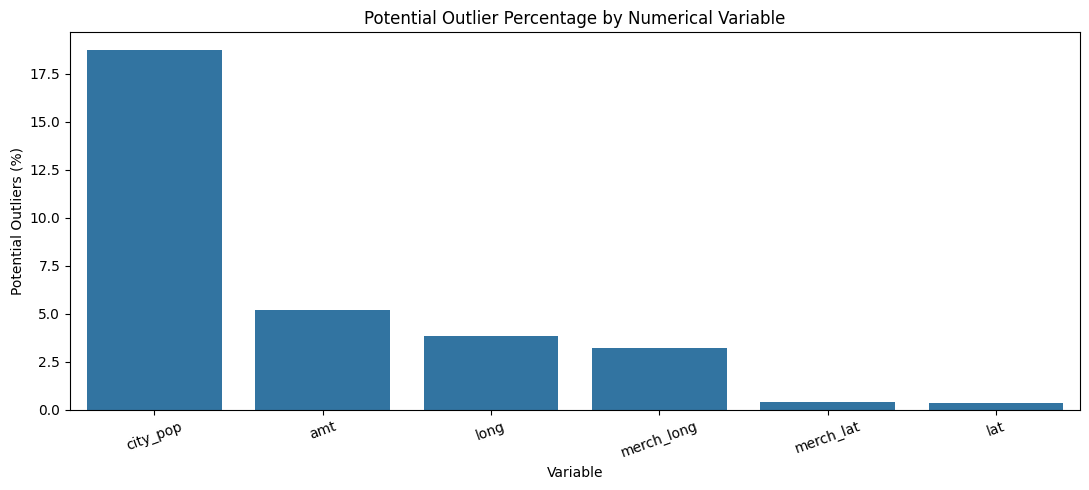

Observation 1: 'city_pop' has the highest proportion of IQR-flagged values (18.72%).
Observation 2: These observations should be investigated rather than automatically deleted, because extreme transaction/location values can be legitimate.


In [26]:

# ============================================================
# 8.2 OUTLIER COUNTS BAR CHART
# ============================================================

if not outlier_summary.empty:
    plt.figure(figsize=(11, 5))
    sns.barplot(
        data=outlier_summary,
        x="variable",
        y="outlier_%",
    )
    plt.title("Potential Outlier Percentage by Numerical Variable")
    plt.xlabel("Variable")
    plt.ylabel("Potential Outliers (%)")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

    highest = outlier_summary.iloc[0]

    print(
        f"Observation 1: '{highest['variable']}' has the highest proportion of "
        f"IQR-flagged values ({highest['outlier_%']:.2f}%)."
    )
    print(
        "Observation 2: These observations should be investigated rather than "
        "automatically deleted, because extreme transaction/location values can be legitimate."
    )



## 9. Outlier Handling Decision

For this EDA, potential outliers are **identified and reported**, not automatically removed.

This is important because:
- a large transaction amount may be genuine;
- geographical coordinates may contain legitimate extremes;
- removing observations solely because they fall outside an IQR boundary can remove meaningful information;
- for a fraud-detection problem, rare observations can be especially informative.

Possible future treatments, depending on the modeling objective:
- retain them;
- log-transform highly right-skewed variables such as `amt`;
- winsorize/cap extreme values;
- use robust models/statistics;
- investigate suspicious records using domain rules.

Any removal should be justified and documented.


In [27]:

# ============================================================
# 10. AUTOMATIC EDA SUMMARY
# ============================================================

print("=" * 70)
print("EDA SUMMARY")
print("=" * 70)

print(f"Dataset size: {df.shape[0]:,} rows × {df.shape[1]} columns")

total_missing = int(df.isna().sum().sum())
print(f"Total missing values: {total_missing:,}")

print(f"Duplicate rows: {df.duplicated().sum():,}")

if "is_fraud" in df.columns:
    fraud_rate = df["is_fraud"].mean() * 100
    print(f"Fraud-class percentage: {fraud_rate:.4f}%")

if "amt" in df.columns:
    amt_series = pd.to_numeric(df["amt"], errors="coerce").dropna()
    print(f"Median transaction amount: {amt_series.median():.2f}")
    print(f"Mean transaction amount: {amt_series.mean():.2f}")
    print(f"Transaction amount skewness: {amt_series.skew():.2f}")

print("\nNumerical variables analysed:")
print(numeric_cols)

print("\nCategorical variables analysed:")
print(categorical_cols + topn_cols)

print("\nNote: No previously completed bivariate/multivariate analyses were repeated.")


EDA SUMMARY
Dataset size: 1,296,675 rows × 23 columns
Total missing values: 0
Duplicate rows: 0
Fraud-class percentage: 0.5789%
Median transaction amount: 47.52
Mean transaction amount: 70.35
Transaction amount skewness: 42.28

Numerical variables analysed:
['amt', 'city_pop', 'lat', 'long', 'merch_lat', 'merch_long']

Categorical variables analysed:
['category', 'gender', 'state', 'job', 'merchant', 'city']

Note: No previously completed bivariate/multivariate analyses were repeated.



# 11. FINAL OBSERVATIONS FOR REPORT

### Dataset Understanding
- The dataset contains transaction-level records with numerical, categorical, geographic and fraud-label variables.
- The requested EDA separates numerical distributions, categorical distributions, data quality and class balance.

### Data Quality
- Missing values and duplicates are explicitly checked rather than assumed.
- Numerical sanity checks identify invalid or unusual values that may require further investigation.

### Class Imbalance
- The fraud target is highly imbalanced, so model evaluation should not rely only on accuracy.

### Numerical Variables
- Histograms/KDE plots reveal distribution shape, skewness and concentration.
- Boxplots highlight spread and potential extreme observations.
- `amt` receives additional IQR-based analysis because transaction amount is particularly important for understanding the dataset.

### Categorical Variables
- Countplots show the most frequent categories for `category`, `gender` and `state`.
- High-cardinality variables such as `job`, `merchant` and `city` are summarized using top-N charts for readability.

### Outliers
- IQR-based outlier detection is used as a statistical screening method.
- Potential outliers are not automatically treated as errors; they must be investigated using domain knowledge before removal or transformation.

> **Important:** Run all cells with the actual `fraudTrain.csv` to generate the exact numeric observations for your copy of the dataset.



## Dataset Source

Kartik Shenoy, **Credit Card Transactions Fraud Detection Dataset**, Kaggle.

The dataset is a simulated credit-card transaction dataset generated using the Sparkov data-generation approach. It contains legitimate and fraudulent transactions and includes transaction amount, merchant/category, cardholder location, merchant location and other attributes.

Source: https://www.kaggle.com/datasets/kartik2112/fraud-detection
